In [1]:
import os
import numpy as np
import scvelo as scv
import scanpy as sc
import pandas as pd
import topovelo as tpv
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = ''
DATA_NAME = 'slide-seq-neural-tube'

In [3]:
adata = sc.read(os.path.join(DATA_DIR, f'{DATA_NAME}_pp.h5ad'))

In [4]:
adata.obs['clusters'] = adata.obs['cell_type'].to_numpy()

In [5]:
FIG_DIR='./figures/slide-seq-neural-tube'
MODEL_DIR = './checkpoints/slide-seq-neural-tube'
DATA_DIR = ''

# (Optional) Select spatially highly variable genes
We already performed this step.

In [ ]:
df_gene = pd.read_csv('')

In [ ]:
variable_genes = df_gene.index.to_numpy().astype(str)
in_adata = np.array([x in adata.var_names for x in variable_genes])
variable_genes = variable_genes[in_adata]

In [ ]:
adata._inplace_subset_var(variable_genes[:500])

In [ ]:
scv.pp.filter_genes(adata, min_shared_counts=10)
scv.pp.normalize_per_cell(adata)
scv.pp.log1p(adata)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
scv.tl.umap(adata)

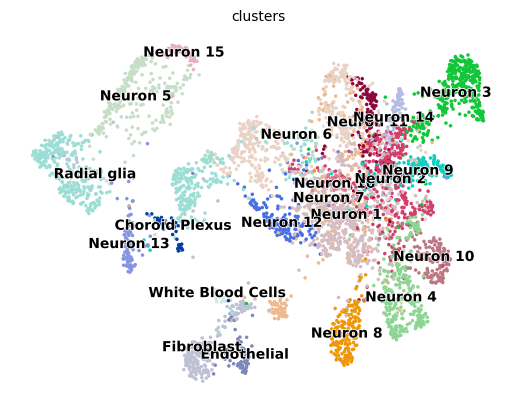

In [16]:
scv.pl.scatter(adata)

# Build a spatial graph

Ball Tree: average number of neighbors: 24.1


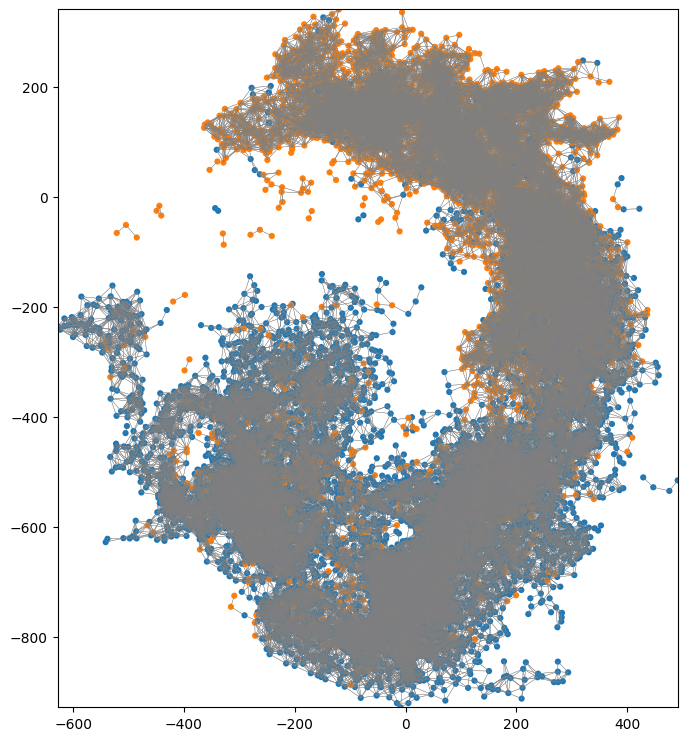

In [6]:
tpv.build_spatial_graph(adata, 'X_spatial_registered', method='BallTree', radius=36.5)
tpv.plotting.plot_spatial_graph(adata, basis='spatial_registered', width=8)

In [8]:
adata.obsp

PairwiseArrays with keys: connectivities, distances, spatial_graph

# TopoVelo (GAT)

In [9]:
figure_path = f'{FIG_DIR}/gat'
model_path = f'{MODEL_DIR}/gat'

spatial_key = 'X_spatial_registered'
vae = tpv.VAE(
    adata, 
    tmax=20, 
    dim_z=7, 
    dim_coord=3,
    spatial_graph_key='spatial_graph',
    device='cuda:0',
    graph_decoder=True,
    attention=True,
    init_ton_zero=True
)
config = {
    'batch_size':512,
}
vae.train(adata,
          adata.obsp['spatial_graph'],
          spatial_key,
          config=config,
          plot=False,
          figure_path=figure_path,
          embed='spatial')
vae.save_model(model_path, 'encoder', 'decoder')
vae.save_anndata(adata, 'gat', DATA_DIR, file_name="adata_out.h5ad")

Estimating ODE parameters...


  0%|          | 0/247 [00:00<?, ?it/s]

  0%|          | 0/247 [00:00<?, ?it/s]

Reinitialize the regular ODE parameters based on estimated global latent time.


  0%|          | 0/247 [00:00<?, ?it/s]

*********               Creating a Graph Dataset              *********
*********                      Finished.                      *********
--------------------------- Train a TopoVelo ---------------------------
*********                 Creating optimizers                 *********
*********                      Finished.                      *********
*********                    Start training                   *********
*********                      Stage  1                       *********
*********       Stage 1: Early Stop Triggered at epoch 220.       *********
Summary: 
Train ELBO = 248.852
Test ELBO = 251.678
Total Time =   0 h : 24 m : 29 s

*********                      Stage  2                       *********


Calculating KNN:   0%|          | 0/11378 [00:00<?, ?it/s]

Stage 2: Early Stop Triggered at round 15.
Final: Train ELBO = 825.880,	Test ELBO = 829.261
*********              Finished. Total Time =   1 h :  2 m :  3 s             *********


In [10]:
adata.shape

(11378, 247)